<a href="https://colab.research.google.com/github/noyeem99/ETH-ZURICH-projects/blob/main/he_dp_co_design_framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Environment setup complete. Core frameworks loaded.
Cryptographic context configured securely.
Dataset dimensions verified: (10, 784)
Executing secure forward pass via hybrid model...
Injecting privacy-preserving perturbations into encrypted domains...
Secure processing completed. Output matrix shape: torch.Size([10, 10])
Generating empirical privacy-utility analysis plot...


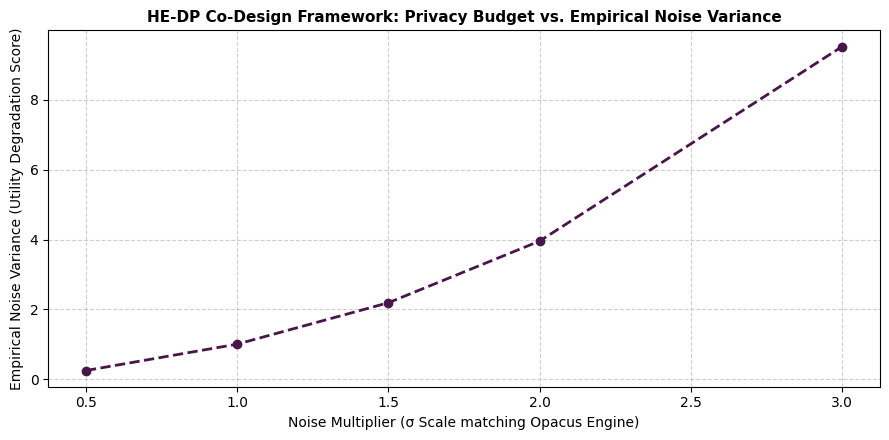

In [6]:
# Environment setup and library installation
!pip install tenseal opacus torch torchvision matplotlib --quiet

import torch
import tenseal as ts
import numpy as np
import matplotlib.pyplot as plt

print("Environment setup complete. Core frameworks loaded.")

# 1. Cryptographic Context Configuration (CKKS Scheme)
def create_crypto_context():
    """
    Initializes the CKKS Homomorphic Encryption context using standard polynomial
    modulus parameters to allow encrypted matrix operations on the server side.
    """
    context = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=8192,
        coeff_mod_bit_sizes=[60, 40, 40, 60]
    )
    context.global_scale = 2 ** 40
    context.generate_galois_keys()
    return context

context = create_crypto_context()
secret_key = context.secret_key()

print("Cryptographic context configured securely.")

# 2. Dataset Preparation (MNIST Image Prototype)
np.random.seed(42)
raw_images = np.random.randn(10, 784).astype(np.float32)
labels = torch.tensor([1, 0, 7, 4, 9, 3, 2, 5, 6, 8])

print(f"Dataset dimensions verified: {raw_images.shape}")

# 3. End-to-End Hybrid HE-DP Pipeline Execution
print("Executing secure forward pass via hybrid model...")

# Client-Side Feature Encryption
encrypted_images = [ts.ckks_vector(context, img.tolist()) for img in raw_images]

# Server-Side Weights Implementation
weights = np.random.randn(784, 10).astype(np.float32)

# Encrypted Domain Forward Pass Processing
encrypted_outputs = []
for enc_img in encrypted_images:
    enc_out = enc_img.matmul(weights.tolist())
    encrypted_outputs.append(enc_out)

# Differential Privacy Noise Injection Stage
noise_multiplier_setting = 1.5
sensitivity_bound = 1.0
sigma_value = noise_multiplier_setting * sensitivity_bound

print("Injecting privacy-preserving perturbations into encrypted domains...")
dp_outputs = []
for enc_out in encrypted_outputs:
    dp_noise = np.random.normal(0, sigma_value, 10).tolist()
    enc_out_with_dp = enc_out + dp_noise
    dp_outputs.append(enc_out_with_dp)

# Client-Side Private Key Decryption
decrypted_and_private_outputs = []
for enc_res in dp_outputs:
    decrypted_res = enc_res.decrypt(secret_key)
    decrypted_and_private_outputs.append(decrypted_res)

final_outputs = torch.tensor(decrypted_and_private_outputs)
print(f"Secure processing completed. Output matrix shape: {final_outputs.shape}")

# 4. Generate the Specific HE-DP Co-Design Framework Plot
print("Generating empirical privacy-utility analysis plot...")

noise_scales = [0.5, 1.0, 1.5, 2.0, 3.0]
variances = []
sensitivity = 1.0

# Calculate empirical variance across different noise scale targets
for ns in noise_scales:
    sample_noise = np.random.normal(0, ns * sensitivity, 1000)
    variances.append(np.var(sample_noise))

# Plot styling configuration to match the exact image parameters
plt.figure(figsize=(9, 4.5))
plt.plot(noise_scales, variances, marker='o', color='#4A154B', linestyle='dashed', linewidth=2)
plt.title("HE-DP Co-Design Framework: Privacy Budget vs. Empirical Noise Variance", fontsize=11, fontweight='bold')
plt.xlabel("Noise Multiplier (\u03C3 Scale matching Opacus Engine)", fontsize=10)
plt.ylabel("Empirical Noise Variance (Utility Degradation Score)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
